In [ ]:
import os, sys, subprocess, textwrap, json, time, shutil
from pathlib import Path

def run(cmd):
    print(f"\n$ {cmd}")
    return subprocess.run(cmd, shell=True, text=True, capture_output=False)

run(f'{sys.executable} -m pip install -q --no-cache-dir -U "pillow>=10.4.0,<12" reportlab pandas matplotlib docling-core docling-parse')

try:
    from PIL import Image, ImageDraw
except ImportError:
    print("\nPillow import failed because Colab has a mixed PIL installation.")
    print("Reinstalling Pillow and restarting runtime. After restart, run this same cell again.")
    run(f'{sys.executable} -m pip uninstall -y pillow PIL')
    run(f'{sys.executable} -m pip install -q --no-cache-dir --force-reinstall "pillow>=10.4.0,<12"')
    os.kill(os.getpid(), 9)

import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import Table, TableStyle
from reportlab.pdfgen import canvas

from docling_core.types.doc.page import TextCellUnit
from docling_parse.pdf_parser import DoclingPdfParser

print("Environment ready.")
print("Python:", sys.version.split()[0])

WORKDIR = Path("/content/docling_parse_advanced_tutorial")
WORKDIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = WORKDIR / "advanced_docling_parse_demo.pdf"
OUT_DIR = WORKDIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

DEMO_IMAGE_PATH = WORKDIR / "demo_bitmap.png"

In [ ]:
def create_demo_image(path):
    img = Image.new("RGB", (320, 180), "white")
    draw = ImageDraw.Draw(img)
    draw.rectangle([20, 20, 300, 160], outline="black", width=3)
    draw.ellipse([55, 45, 145, 135], outline="black", width=4)
    draw.line([180, 140, 285, 45], fill="black", width=4)
    draw.text((45, 145), "Embedded bitmap image", fill="black")
    img.save(path)

create_demo_image(DEMO_IMAGE_PATH)

def build_pdf(pdf_path):
    c = canvas.Canvas(str(pdf_path), pagesize=A4)
    width, height = A4

    c.setFont("Helvetica-Bold", 20)
    c.drawString(60, height - 70, "Docling Parse Advanced PDF Parsing Tutorial")

    c.setFont("Helvetica", 11)
    intro = (
        "This generated document is designed for testing text extraction, coordinate parsing, "
        "line grouping, vector path detection, bitmap resources, and layout-aware reconstruction."
    )

    text_obj = c.beginText(60, height - 105)
    text_obj.setLeading(15)
    for line in textwrap.wrap(intro, width=90):
        text_obj.textLine(line)
    c.drawText(text_obj)

    c.setFont("Helvetica-Bold", 14)
    c.drawString(60, height - 170, "1. Two-column text region")

    left_para = (
        "The left column contains compact explanatory text. A parser should expose words, "
        "characters, and line-level cells along with coordinates. These coordinates allow us "
        "to reconstruct reading order and inspect the spatial structure of a page."
    )

    right_para = (
        "The right column contains a separate paragraph. In document AI pipelines, layout "
        "features are useful for retrieval, table extraction, chunking, and downstream RAG "
        "applications where page position can matter."
    )

    y_start = height - 200

    left_text = c.beginText(60, y_start)
    left_text.setFont("Helvetica", 10)
    left_text.setLeading(13)
    for line in textwrap.wrap(left_para, width=42):
        left_text.textLine(line)
    c.drawText(left_text)

    right_text = c.beginText(325, y_start)
    right_text.setFont("Helvetica", 10)
    right_text.setLeading(13)
    for line in textwrap.wrap(right_para, width=42):
        right_text.textLine(line)
    c.drawText(right_text)

    c.setStrokeColor(colors.darkblue)
    c.setLineWidth(2)
    c.rect(55, height - 315, 225, 130, stroke=1, fill=0)
    c.rect(320, height - 315, 225, 130, stroke=1, fill=0)

    c.setStrokeColor(colors.darkgreen)
    c.setLineWidth(3)
    c.circle(140, height - 390, 40, stroke=1, fill=0)
    c.line(220, height - 430, 310, height - 355)

    c.setFont("Helvetica-Bold", 14)
    c.setFillColor(colors.black)
    c.drawString(60, height - 470, "2. Simple table-like structure")

    data = [
        ["Section", "Signal", "Expected parser behavior"],
        ["Text", "Words and lines", "Return text cells with coordinates"],
        ["Vector", "Boxes and lines", "Expose page path/vector resources"],
        ["Bitmap", "Embedded image", "Expose or render image resources"],
    ]

    table = Table(data, colWidths=[100, 130, 260])
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 0.7, colors.black),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE", (0, 0), (-1, -1), 9),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ]))

    table.wrapOn(c, width, height)
    table.drawOn(c, 60, height - 590)

    c.setFont("Helvetica", 9)
    c.drawString(60, 55, "Page 1: generated programmatic PDF with text, table-like layout, and vector paths.")
    c.showPage()

    c.setFont("Helvetica-Bold", 18)
    c.drawString(60, height - 70, "Page 2: Bitmap, Dense Text, and Reading Order")

    c.setFont("Helvetica", 10)
    dense = (
        "This page includes an embedded bitmap image and several short blocks of text. "
        "We use it to test whether rendering works, whether the parser preserves page-level "
        "coordinates, and whether our own reconstruction logic can group words into lines."
    )

    y = height - 105
    for para_idx in range(4):
        tx = c.beginText(60, y)
        tx.setFont("Helvetica", 10)
        tx.setLeading(13)
        for line in textwrap.wrap(f"Block {para_idx + 1}: {dense}", width=92):
            tx.textLine(line)
        c.drawText(tx)
        y -= 70

    c.drawImage(str(DEMO_IMAGE_PATH), 110, height - 510, width=320, height=180, preserveAspectRatio=True)

    c.setStrokeColor(colors.red)
    c.setLineWidth(2)
    c.roundRect(95, height - 525, 350, 210, 10, stroke=1, fill=0)

    c.setFillColor(colors.black)
    c.setFont("Helvetica-Bold", 12)
    c.drawString(60, height - 570, "Coordinate-aware extraction lets us keep page, text, and position together.")

    c.setFont("Helvetica", 9)
    c.drawString(60, 55, "Page 2: embedded bitmap image and multiple text blocks.")
    c.save()

build_pdf(PDF_PATH)
print("Created PDF:", PDF_PATH)

In [ ]:
def safe_to_dict(obj, max_depth=2):
    if obj is None:
        return None

    if isinstance(obj, (str, int, float, bool)):
        return obj

    if isinstance(obj, (list, tuple)):
        return [safe_to_dict(x, max_depth=max_depth - 1) for x in obj[:50]]

    if isinstance(obj, dict):
        return {
            str(k): safe_to_dict(v, max_depth=max_depth - 1)
            for k, v in list(obj.items())[:50]
        }

    if hasattr(obj, "model_dump"):
        try:
            return obj.model_dump()
        except Exception:
            pass

    if hasattr(obj, "__dict__") and max_depth > 0:
        try:
            return {
                k: safe_to_dict(v, max_depth=max_depth - 1)
                for k, v in obj.__dict__.items()
                if not k.startswith("_")
            }
        except Exception:
            pass

    return str(obj)

def rect_to_dict(rect):
    d = safe_to_dict(rect)

    if isinstance(d, dict):
        return d

    attrs = {}
    for name in [
        "l", "t", "r", "b",
        "left", "top", "right", "bottom",
        "x0", "y0", "x1", "y1",
        "width", "height"
    ]:
        if hasattr(rect, name):
            try:
                attrs[name] = getattr(rect, name)
            except Exception:
                pass

    return attrs if attrs else {"raw": str(rect)}

def get_text_cell_records(page_no, pred_page, unit_type):
    records = []

    try:
        cells = list(pred_page.iterate_cells(unit_type=unit_type))
    except Exception as e:
        print(f"Could not iterate {unit_type} cells on page {page_no}: {e}")
        return records

    for idx, cell in enumerate(cells):
        text = getattr(cell, "text", "")
        rect = getattr(cell, "rect", None)

        records.append({
            "page": page_no,
            "unit": str(unit_type).split(".")[-1],
            "index": idx,
            "text": text,
            "rect": rect_to_dict(rect),
            "raw_cell": safe_to_dict(cell, max_depth=1),
        })

    return records

def count_possible_resources(pred_page):
    resource_summary = {}
    names = dir(pred_page)
    keywords = ["path", "bitmap", "image", "resource", "line", "rect"]

    for name in names:
        lname = name.lower()

        if any(k in lname for k in keywords) and not name.startswith("_"):
            try:
                value = getattr(pred_page, name)

                if callable(value):
                    continue

                try:
                    resource_summary[name] = len(value)
                except Exception:
                    resource_summary[name] = type(value).__name__

            except Exception:
                pass

    return resource_summary

parser = DoclingPdfParser()

start = time.perf_counter()
pdf_doc = parser.load(path_or_stream=str(PDF_PATH))
load_time = time.perf_counter() - start

print(f"\nLoaded PDF in {load_time:.3f} seconds.")

all_records = []
page_summaries = []
rendered_paths = []

parse_start = time.perf_counter()

for page_no, pred_page in pdf_doc.iterate_pages():
    print(f"\n--- Page {page_no} ---")

    word_records = get_text_cell_records(page_no, pred_page, TextCellUnit.WORD)
    char_records = get_text_cell_records(page_no, pred_page, TextCellUnit.CHAR)
    line_records = get_text_cell_records(page_no, pred_page, TextCellUnit.LINE)

    all_records.extend(word_records)
    all_records.extend(char_records)
    all_records.extend(line_records)

    resource_summary = count_possible_resources(pred_page)

    page_summaries.append({
        "page": page_no,
        "words": len(word_records),
        "chars": len(char_records),
        "lines": len(line_records),
        "possible_resource_attributes": resource_summary,
    })

    print("Words:", len(word_records))
    print("Characters:", len(char_records))
    print("Lines:", len(line_records))
    print("Possible resource attributes:", resource_summary)

    print("\nFirst 20 extracted words:")
    print(" ".join([r["text"] for r in word_records[:20]]))

    for unit_name, unit_type in [
        ("word", TextCellUnit.WORD),
        ("char", TextCellUnit.CHAR),
        ("line", TextCellUnit.LINE),
    ]:
        try:
            img = pred_page.render_as_image(cell_unit=unit_type)
            out_img = OUT_DIR / f"page_{page_no}_{unit_name}_overlay.png"
            img.save(out_img)
            rendered_paths.append(out_img)
            print("Saved rendered overlay:", out_img)
        except Exception as e:
            print(f"Could not render {unit_name} overlay for page {page_no}: {e}")

parse_time = time.perf_counter() - parse_start

In [ ]:
records_path = OUT_DIR / "docling_parse_cells.json"
with open(records_path, "w", encoding="utf-8") as f:
    json.dump(all_records, f, indent=2, ensure_ascii=False)

summary_path = OUT_DIR / "page_summaries.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(page_summaries, f, indent=2, ensure_ascii=False)

flat_rows = []

for r in all_records:
    rect = r.get("rect", {})

    row = {
        "page": r["page"],
        "unit": r["unit"],
        "index": r["index"],
        "text": r["text"],
    }

    if isinstance(rect, dict):
        for k, v in rect.items():
            if isinstance(v, (str, int, float, bool)) or v is None:
                row[f"rect_{k}"] = v
            else:
                row[f"rect_{k}"] = str(v)

    flat_rows.append(row)

df = pd.DataFrame(flat_rows)

csv_path = OUT_DIR / "docling_parse_cells.csv"
df.to_csv(csv_path, index=False)

summary_df = pd.DataFrame(page_summaries)

summary_csv_path = OUT_DIR / "page_summaries.csv"
summary_df.to_csv(summary_csv_path, index=False)

print("\nSaved structured outputs:")
print(records_path)
print(csv_path)
print(summary_path)
print(summary_csv_path)

print("\nPage summary:")
display(summary_df)

print("\nCell dataframe sample:")
display(df.head(20))

def extract_rect_numbers(rect):
    if not isinstance(rect, dict):
        return None

    possible_sets = [
        ("l", "t", "r", "b"),
        ("left", "top", "right", "bottom"),
        ("x0", "y0", "x1", "y1"),
    ]

    for keys in possible_sets:
        if all(k in rect for k in keys):
            try:
                vals = [float(rect[k]) for k in keys]
                return vals
            except Exception:
                pass

    numeric = []

    for v in rect.values():
        try:
            numeric.append(float(v))
        except Exception:
            pass

    if len(numeric) >= 4:
        return numeric[:4]

    return None

word_df = df[df["unit"].str.contains("WORD", case=False, na=False)].copy()

if len(word_df) == 0:
    word_df = df[df["unit"].str.contains("word", case=False, na=False)].copy()

coords = []

for _, row in word_df.iterrows():
    rect_data = {}

    for col in word_df.columns:
        if col.startswith("rect_"):
            rect_data[col.replace("rect_", "")] = row[col]

    nums = extract_rect_numbers(rect_data)
    coords.append(nums)

word_df["coord_numbers"] = coords
word_df = word_df[word_df["coord_numbers"].notna()].copy()

if len(word_df) > 0:
    word_df["x0"] = word_df["coord_numbers"].apply(lambda x: min(x[0], x[2]))
    word_df["x1"] = word_df["coord_numbers"].apply(lambda x: max(x[0], x[2]))
    word_df["y0"] = word_df["coord_numbers"].apply(lambda x: min(x[1], x[3]))
    word_df["y1"] = word_df["coord_numbers"].apply(lambda x: max(x[1], x[3]))
    word_df["y_mid"] = (word_df["y0"] + word_df["y1"]) / 2

    reconstructed_pages = {}

    for page, g in word_df.groupby("page"):
        g = g.sort_values(["y_mid", "x0"]).copy()

        y_values = sorted(g["y_mid"].tolist())
        line_bins = []
        threshold = 8.0

        for y in y_values:
            placed = False

            for line in line_bins:
                if abs(line["center"] - y) <= threshold:
                    line["values"].append(y)
                    line["center"] = sum(line["values"]) / len(line["values"])
                    placed = True
                    break

            if not placed:
                line_bins.append({"center": y, "values": [y]})

        def assign_line(y):
            return min(range(len(line_bins)), key=lambda i: abs(line_bins[i]["center"] - y))

        g["line_id"] = g["y_mid"].apply(assign_line)

        lines = []

        for line_id, lg in g.groupby("line_id"):
            lg = lg.sort_values("x0")
            line_text = " ".join(lg["text"].astype(str).tolist())
            lines.append((lg["y_mid"].mean(), line_text))

        lines = sorted(lines, key=lambda x: x[0])
        reconstructed_text = "\n".join([line for _, line in lines])
        reconstructed_pages[int(page)] = reconstructed_text

    recon_path = OUT_DIR / "layout_aware_reconstructed_text.json"

    with open(recon_path, "w", encoding="utf-8") as f:
        json.dump(reconstructed_pages, f, indent=2, ensure_ascii=False)

    print("\nLayout-aware reconstructed text:")

    for page, text in reconstructed_pages.items():
        print(f"\n===== PAGE {page} =====")
        print(text[:2500])

    print("\nSaved reconstruction:", recon_path)

else:
    print("\nCould not build coordinate-based reconstruction because rectangle coordinates were not exposed in a numeric form.")


$ /usr/bin/python3 -m pip install -q --no-cache-dir -U "pillow>=10.4.0,<12" reportlab pandas matplotlib docling-core docling-parse
Environment ready.
Python: 3.12.13
Created PDF: /content/docling_parse_advanced_tutorial/advanced_docling_parse_demo.pdf

Loaded PDF in 0.001 seconds.

--- Page 1 ---
Words: 141
Characters: 983
Lines: 30
Possible resource attributes: {'bitmap_resources': 0, 'has_lines': 'bool', 'image': 'NoneType', 'lines': 0, 'textline_cells': 30}

First 20 extracted words:
Docling Parse Advanced PDF Parsing Tutorial This generated document is designed for testing text extraction, coordinate parsing, line grouping, vector


/tmp/ipykernel_12451/3575799934.py:271: DeprecationWarning: Use `shapes` instead.
  value = getattr(pred_page, name)


Saved rendered overlay: /content/docling_parse_advanced_tutorial/outputs/page_1_word_overlay.png
Saved rendered overlay: /content/docling_parse_advanced_tutorial/outputs/page_1_char_overlay.png
Saved rendered overlay: /content/docling_parse_advanced_tutorial/outputs/page_1_line_overlay.png

--- Page 2 ---
Words: 187
Characters: 1171
Lines: 15
Possible resource attributes: {'bitmap_resources': 1, 'has_lines': 'bool', 'image': 'NoneType', 'lines': 0, 'textline_cells': 15}

First 20 extracted words:
Page 2: Bitmap, Dense Text, and Reading Order Block 1: This page includes an embedded bitmap image and several short
Saved rendered overlay: /content/docling_parse_advanced_tutorial/outputs/page_2_word_overlay.png
Saved rendered overlay: /content/docling_parse_advanced_tutorial/outputs/page_2_char_overlay.png
Saved rendered overlay: /content/docling_parse_advanced_tutorial/outputs/page_2_line_overlay.png

Saved structured outputs:
/content/docling_parse_advanced_tutorial/outputs/docling_parse_

,page,words,chars,lines,possible_resource_attributes
0,1,141,983,30,"{'bitmap_resources': 0, 'has_lines': 'bool', '..."
1,2,187,1171,15,"{'bitmap_resources': 1, 'has_lines': 'bool', '..."



Cell dataframe sample:


,page,unit,index,text,rect_r_x0,rect_r_y0,rect_r_x1,rect_r_y1,rect_r_x2,rect_r_y2,rect_r_x3,rect_r_y3,rect_coord_origin
0,1,word,0,Docling,60.000,767.7498,133.340,767.7498,133.340,786.2498,60.000,786.2498,BOTTOMLEFT
1,1,word,1,Parse,138.900,767.7498,193.380,767.7498,193.380,786.2498,138.900,786.2498,BOTTOMLEFT
2,1,word,2,Advanced,198.940,767.7498,294.520,767.7498,294.520,786.2498,198.940,786.2498,BOTTOMLEFT
3,1,word,3,PDF,300.080,767.7498,340.080,767.7498,340.080,786.2498,300.080,786.2498,BOTTOMLEFT
4,1,word,4,Parsing,345.640,767.7498,419.000,767.7498,419.000,786.2498,345.640,786.2498,BOTTOMLEFT
5,1,word,5,Tutorial,424.560,767.7498,497.900,767.7498,497.900,786.2498,424.560,786.2498,BOTTOMLEFT
6,1,word,6,This,60.000,734.6128,80.779,734.6128,80.779,744.7878,60.000,744.7878,BOTTOMLEFT
7,1,word,7,generated,83.837,734.6128,133.370,734.6128,133.370,744.7878,83.837,744.7878,BOTTOMLEFT
8,1,word,8,document,136.428,734.6128,184.729,734.6128,184.729,744.7878,136.428,744.7878,BOTTOMLEFT
9,1,word,9,is,187.787,734.6128,195.729,734.6128,195.729,744.7878,187.787,744.7878,BOTTOMLEFT



Layout-aware reconstructed text:

===== PAGE 1 =====
Page 1: generated programmatic PDF with text, table-like layout, and vector paths.
Bitmap Embedded image Expose or render image resources
Vector Boxes and lines Expose page path/vector resources
Text Words and lines Return text cells with coordinates
Section Signal Expected parser behavior
2. Simple table-like structure
inspect the spatial structure of a page. matter.
allow us to reconstruct reading order and RAG applications where page position can
along with coordinates. These coordinates table extraction, chunking, and downstream
words, characters, and line-level cells layout features are useful for retrieval,
explanatory text. A parser should expose paragraph. In document AI pipelines,
The left column contains compact The right column contains a separate
1. Two-column text region
grouping, vector path detection, bitmap resources, and layout-aware reconstruction.
This generated document is designed for testing text extraction, co

,doc_key,page_number,success,error_message,word_count,total_time
0,key=/content/docling_parse_advanced_tutorial/a...,1,True,,141,0.098633
1,key=/content/docling_parse_advanced_tutorial/a...,2,True,,187,0.141510


Saved threaded results: /content/docling_parse_advanced_tutorial/outputs/threaded_parse_results.json

Benchmark:
{
  "standard_load_time_seconds": 0.0005408339998211886,
  "standard_iterate_parse_time_seconds": 2.4444991780001146,
  "threaded_total_time_seconds": 0.29125722800017684,
  "total_cells_extracted": 2527,
  "output_dir": "/content/docling_parse_advanced_tutorial/outputs"
}

Checking CLI availability...
docling-parse CLI: None
CLI was not found on PATH, but the Python API worked.

Generated files:
/content/docling_parse_advanced_tutorial/outputs/benchmark.json
/content/docling_parse_advanced_tutorial/outputs/docling_parse_cells.csv
/content/docling_parse_advanced_tutorial/outputs/docling_parse_cells.json
/content/docling_parse_advanced_tutorial/outputs/layout_aware_reconstructed_text.json
/content/docling_parse_advanced_tutorial/outputs/page_1_char_overlay.png
/content/docling_parse_advanced_tutorial/outputs/page_1_line_overlay.png
/content/docling_parse_advanced_tutorial/out

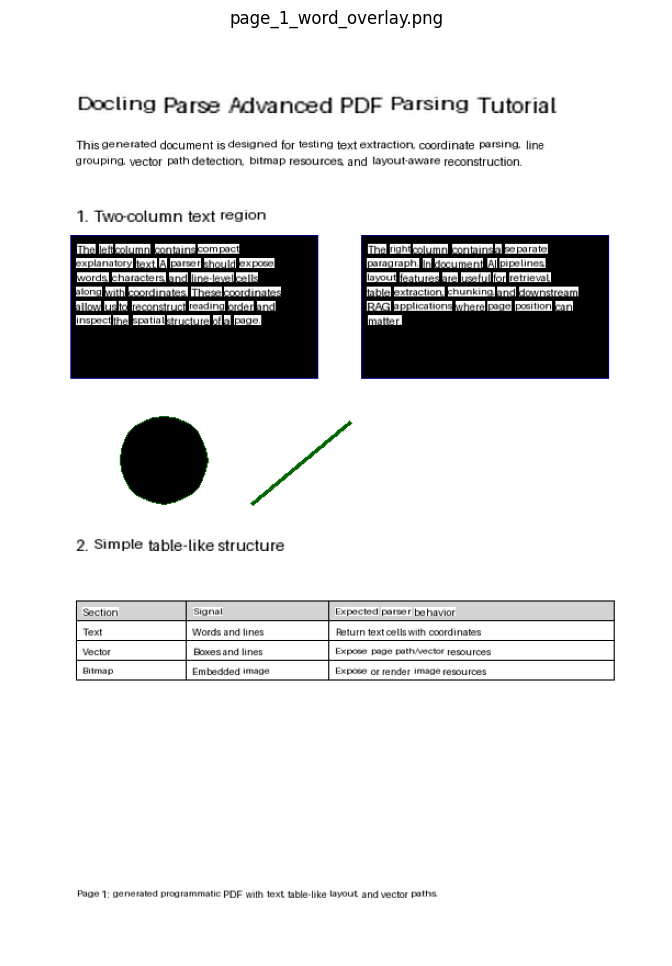

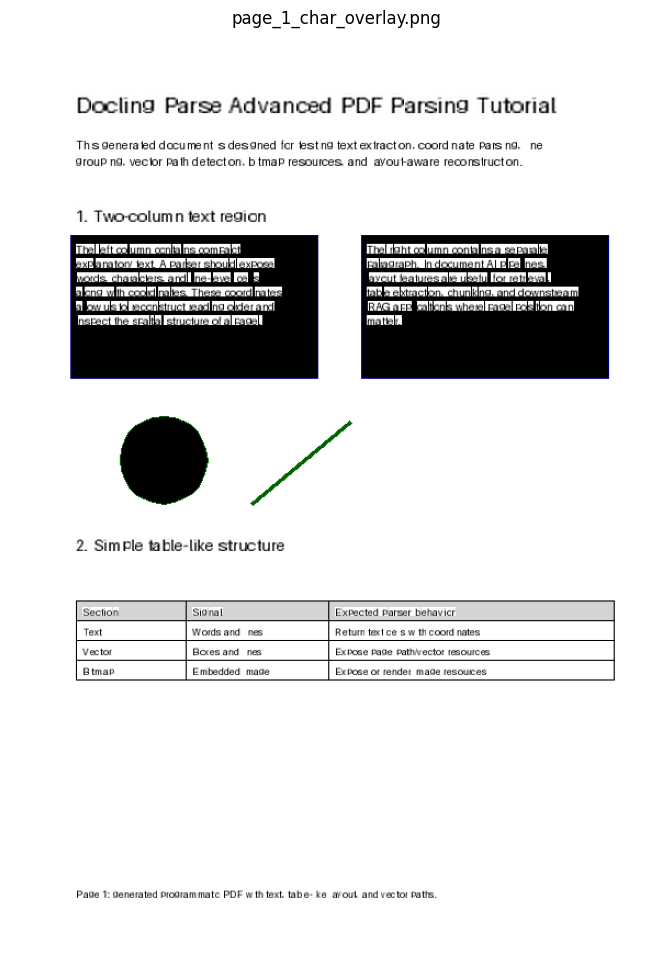

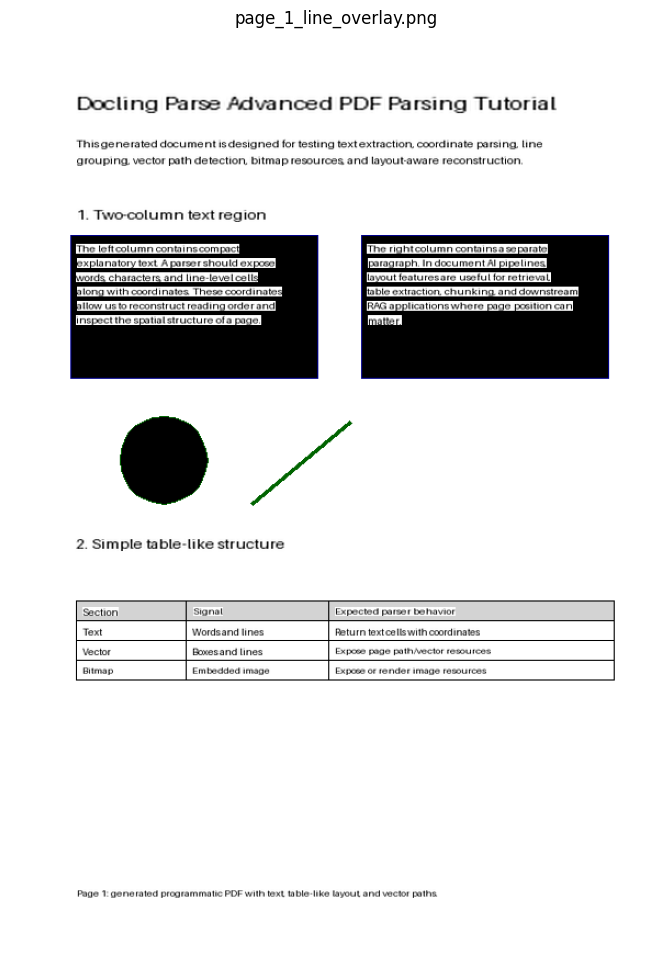

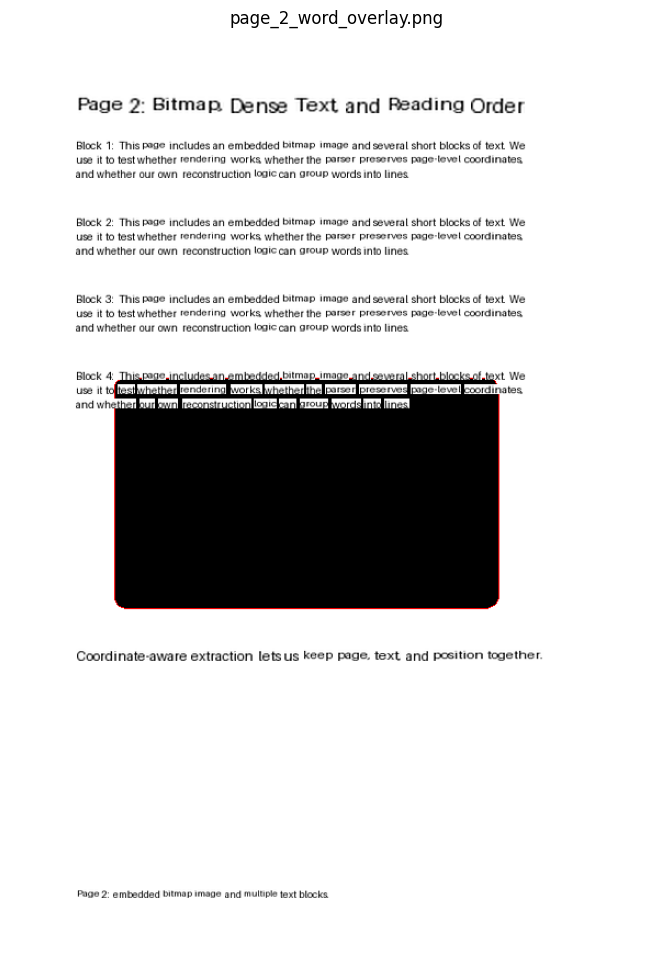

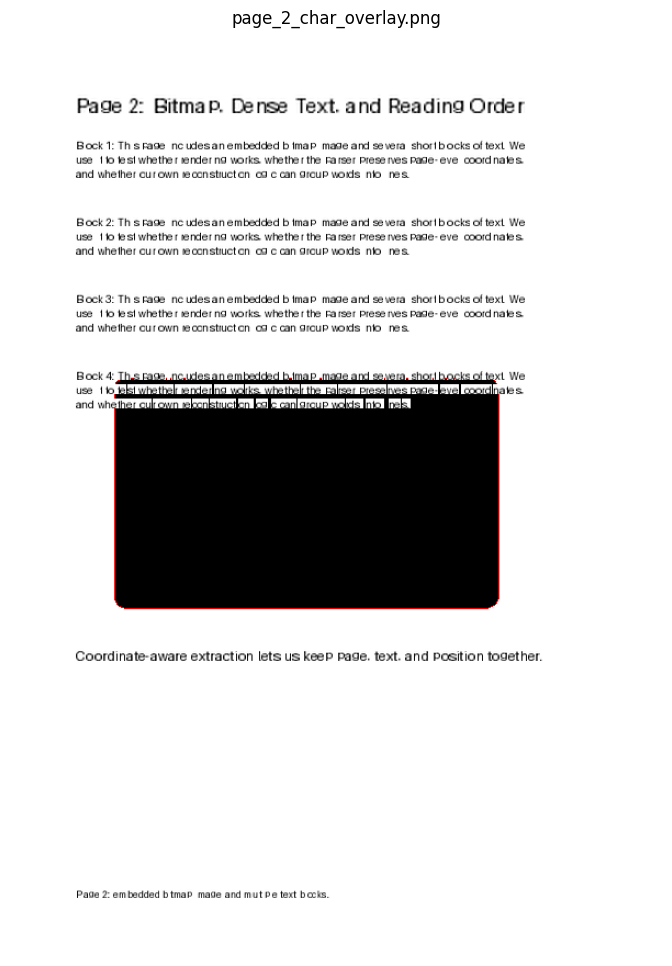

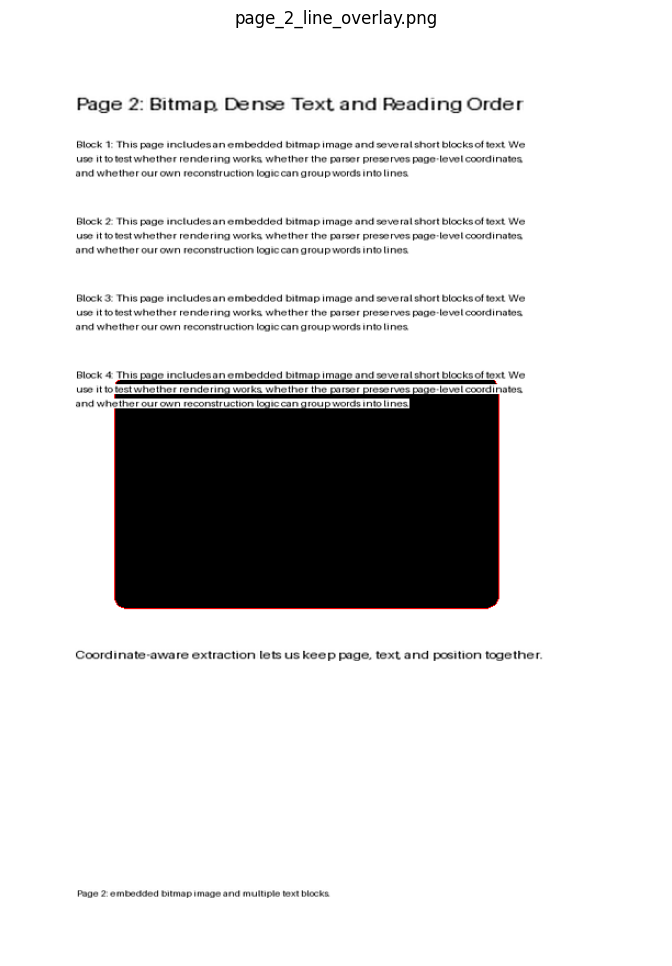


Tutorial complete.
Main outputs are stored in: /content/docling_parse_advanced_tutorial/outputs


In [1]:
print("\nAttempting threaded parsing benchmark...")

threaded_results = []
threaded_available = True

try:
    from docling_parse.pdf_parser import DoclingThreadedPdfParser, ThreadedPdfParserConfig
    from docling_parse.pdf_parsers import DecodePageConfig

    parser_config = ThreadedPdfParserConfig(
        loglevel="fatal",
        threads=4,
        max_concurrent_results=32,
    )

    decode_config = DecodePageConfig()

    threaded_parser = DoclingThreadedPdfParser(
        parser_config=parser_config,
        decode_config=decode_config,
    )

    t0 = time.perf_counter()

    doc_key = threaded_parser.load(str(PDF_PATH))
    page_count = threaded_parser.page_count(doc_key)

    print("Threaded doc key:", doc_key)
    print("Threaded page count:", page_count)

    for result in threaded_parser.iterate_results():
        item = {
            "doc_key": str(getattr(result, "doc_key", "")),
            "page_number": getattr(result, "page_number", None),
            "success": getattr(result, "success", None),
            "error_message": getattr(result, "error_message", None),
        }

        if getattr(result, "success", False):
            seg_page = result.get_page()
            timings = result.get_timings()

            item["word_count"] = len(getattr(seg_page, "word_cells", []))

            try:
                item["total_time"] = timings.total()
            except Exception:
                item["total_time"] = str(timings)

        threaded_results.append(item)

    threaded_time = time.perf_counter() - t0

except Exception as e:
    threaded_available = False
    threaded_time = None
    print("Threaded parser is not available or failed in this environment.")
    print("Error:", repr(e))

if threaded_available:
    threaded_path = OUT_DIR / "threaded_parse_results.json"

    with open(threaded_path, "w", encoding="utf-8") as f:
        json.dump(threaded_results, f, indent=2, ensure_ascii=False)

    threaded_df = pd.DataFrame(threaded_results)

    print("\nThreaded parsing results:")
    display(threaded_df)

    print("Saved threaded results:", threaded_path)

benchmark = {
    "standard_load_time_seconds": load_time,
    "standard_iterate_parse_time_seconds": parse_time,
    "threaded_total_time_seconds": threaded_time,
    "total_cells_extracted": len(all_records),
    "output_dir": str(OUT_DIR),
}

benchmark_path = OUT_DIR / "benchmark.json"

with open(benchmark_path, "w", encoding="utf-8") as f:
    json.dump(benchmark, f, indent=2)

print("\nBenchmark:")
print(json.dumps(benchmark, indent=2))

print("\nChecking CLI availability...")

cli = shutil.which("docling-parse")
print("docling-parse CLI:", cli)

if cli:
    cli_result = subprocess.run(
        "docling-parse -h",
        shell=True,
        text=True,
        capture_output=True,
    )

    print(cli_result.stdout[:1000])

else:
    print("CLI was not found on PATH, but the Python API worked.")

print("\nGenerated files:")

for p in sorted(OUT_DIR.glob("*")):
    print(p)

print("\nRendering saved overlay images in notebook...")

for img_path in rendered_paths[:6]:
    try:
        img = Image.open(img_path)
        plt.figure(figsize=(9, 12))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()
    except Exception as e:
        print("Could not display:", img_path, e)

print("\nTutorial complete.")
print("Main outputs are stored in:", OUT_DIR)